# Lab: Introduction to PyTorch

## Objective
* To study and implement the fundamental concepts of PyTorch — tensors, tensor operations, automatic differentiation (autograd), and a simple neural network
* To understand the underlying theory behind each concept.

## Software Required
- Python 3.x
- PyTorch (`pip install torch`)
- Jupyter Notebook / Google Colab (optional)

---

## 1. Theory

### 1.1 What is PyTorch?
PyTorch is an open-source machine learning framework developed by Meta AI (formerly Facebook AI Research). It is widely used for deep learning research and production because of its:

- **Pythonic nature** – PyTorch code looks and behaves like standard Python/NumPy code, making it easy to learn and debug.
- **Dynamic computation graph** – Unlike older frameworks (e.g., early TensorFlow) that used static graphs, PyTorch builds the computational graph *on the fly* as operations are executed. This is called **define-by-run**. It allows more flexibility, easier debugging, and support for models with varying structure (e.g., RNNs with variable-length input).
- **GPU acceleration** – Tensors can be seamlessly moved between CPU and GPU for faster computation.
- **Automatic differentiation** – PyTorch's `autograd` engine automatically computes gradients, which are essential for training neural networks using backpropagation.

### 1.2 Tensors
A **tensor** is the fundamental data structure in PyTorch, similar to a NumPy array, but with additional capabilities:
1. It can run on a GPU for faster numerical computation.
2. It keeps track of the operations performed on it (needed for automatic differentiation).

Tensors can be of different dimensions:

| Rank | Name   | Example                     |
|------|--------|------------------------------|
| 0    | Scalar | `5`                          |
| 1    | Vector | `[1, 2, 3]`                  |
| 2    | Matrix | `[[1,2],[3,4]]`               |
| 3+   | N-D Tensor | Images, video, batches   |

### 1.3 Autograd (Automatic Differentiation)
Training a neural network requires computing the **gradient of a loss function** with respect to the model's parameters (weights), so the parameters can be updated using **gradient descent**.

PyTorch's `autograd` module automates this process:
- Every tensor has an attribute `requires_grad`. If set to `True`, PyTorch tracks all operations on it.
- Internally, PyTorch builds a **Dynamic Computational Graph (DCG)** — a Directed Acyclic Graph (DAG) — where nodes are tensors and edges are the operations that produced them.
- When `.backward()` is called on a scalar output (usually the loss), PyTorch traverses this graph backward (using the **chain rule** of calculus) and computes the gradient of the output with respect to every tensor that has `requires_grad=True`. These gradients are stored in the tensor's `.grad` attribute.

This process is the computational implementation of **backpropagation**.

### 1.4 Neural Network Building Blocks
PyTorch provides the `torch.nn` module to build neural networks conveniently:
- **`nn.Module`** – The base class for all neural network models. Custom models are created by subclassing it and defining layers in `__init__()` and the forward pass in `forward()`.
- **`nn.Linear(in_features, out_features)`** – Implements a fully connected (dense) layer: `y = xW^T + b`.
- **Activation functions** (e.g., `ReLU`, `Sigmoid`) – Introduce non-linearity so the network can learn complex patterns.
- **Loss functions** (e.g., `nn.MSELoss`, `nn.CrossEntropyLoss`) – Measure how far the model's predictions are from the actual targets.
- **Optimizers** (e.g., `torch.optim.SGD`, `torch.optim.Adam`) – Update model parameters using the gradients computed by autograd, based on a chosen optimization algorithm.

### 1.5 The General Training Loop
Every PyTorch model is trained using the same basic cycle:
1. **Forward pass** – Pass input through the model to get predictions.
2. **Compute loss** – Compare predictions to actual targets using a loss function.
3. **Backward pass** – Call `loss.backward()` to compute gradients via autograd.
4. **Update weights** – Call `optimizer.step()` to update parameters using the gradients.
5. **Zero gradients** – Call `optimizer.zero_grad()` before the next iteration, since gradients accumulate by default in PyTorch.

---

## 2. Program

### 2.1 Installing and Importing PyTorch
```python
# Install PyTorch (run only once, if not already installed)
# !pip install torch

import torch
print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
```

### 2.2 Creating Tensors
```python
import torch

# Creating tensors in different ways
a = torch.tensor([1, 2, 3])              # from a list
b = torch.zeros(2, 3)                    # 2x3 tensor of zeros
c = torch.ones(2, 3)                     # 2x3 tensor of ones
d = torch.rand(2, 3)                     # random values [0,1)
e = torch.arange(0, 10, 2)               # like Python's range()

print("a:", a)
print("b:\n", b)
print("c:\n", c)
print("d:\n", d)
print("e:", e)

# Tensor attributes
print("Shape of d:", d.shape)
print("Datatype of d:", d.dtype)
print("Device of d:", d.device)
```

### 2.3 Tensor Operations
```python
x = torch.tensor([1.0, 2.0, 3.0])
y = torch.tensor([4.0, 5.0, 6.0])

# Element-wise operations
print("Addition:", x + y)
print("Subtraction:", x - y)
print("Multiplication:", x * y)
print("Division:", x / y)

# Matrix multiplication
m1 = torch.rand(2, 3)
m2 = torch.rand(3, 2)
print("Matrix multiplication:\n", torch.matmul(m1, m2))

# Reshaping
z = torch.arange(6)
print("Original:", z)
print("Reshaped (2x3):\n", z.reshape(2, 3))

# NumPy <-> Tensor conversion
import numpy as np
np_array = np.array([1, 2, 3])
tensor_from_np = torch.from_numpy(np_array)
back_to_np = tensor_from_np.numpy()
print("Tensor from NumPy:", tensor_from_np)
```

### 2.4 Autograd Example
```python
import torch

# requires_grad=True tells PyTorch to track operations for gradient computation
x = torch.tensor(2.0, requires_grad=True)

# Define a simple function: y = x^2 + 3x + 1
y = x**2 + 3*x + 1

# Compute dy/dx using backpropagation
y.backward()

print("x:", x.item())
print("y:", y.item())
print("dy/dx at x=2:", x.grad.item())   # Should be 2x + 3 = 7
```

### 2.5 Building a Simple Neural Network
```python
import torch
import torch.nn as nn

# Define a simple feedforward neural network
class SimpleNN(nn.Module):
    def __init__(self, input_size, hidden_size, output_size):
        super(SimpleNN, self).__init__()
        self.layer1 = nn.Linear(input_size, hidden_size)
        self.relu = nn.ReLU()
        self.layer2 = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        x = self.layer1(x)
        x = self.relu(x)
        x = self.layer2(x)
        return x

# Instantiate the model
model = SimpleNN(input_size=4, hidden_size=8, output_size=1)
print(model)

# Dummy input
sample_input = torch.rand(1, 4)
output = model(sample_input)
print("Model output:", output)
```

### 2.6 Complete Training Loop Example
```python
import torch
import torch.nn as nn
import torch.optim as optim

# Dummy dataset: y = 2x + 1
X = torch.tensor([[1.0], [2.0], [3.0], [4.0]])
Y = torch.tensor([[3.0], [5.0], [7.0], [9.0]])

# Simple linear model: y = wx + b
model = nn.Linear(1, 1)

# Loss function and optimizer
criterion = nn.MSELoss()
optimizer = optim.SGD(model.parameters(), lr=0.01)

# Training loop
epochs = 200
for epoch in range(epochs):
    # 1. Forward pass
    predictions = model(X)
    loss = criterion(predictions, Y)

    # 2. Backward pass
    optimizer.zero_grad()   # clear old gradients
    loss.backward()         # compute new gradients

    # 3. Update weights
    optimizer.step()

    if (epoch + 1) % 20 == 0:
        print(f"Epoch [{epoch+1}/{epochs}], Loss: {loss.item():.4f}")

# Final learned parameters
w, b = model.parameters()
print(f"\nLearned weight: {w.item():.4f}, Learned bias: {b.item():.4f}")
print("Expected: weight ≈ 2, bias ≈ 1")
```

**Expected Output (approximate):**
```
Epoch [20/200], Loss: ...
Epoch [40/200], Loss: ...
...
Learned weight: ~2.0000, Learned bias: ~1.0000
```

---

<!-- ## 3. Result / Conclusion
In this lab, the basic building blocks of PyTorch were studied and implemented:
- **Tensors** and their operations (creation, arithmetic, reshaping, NumPy interoperability).
- **Autograd**, which automatically computes gradients using the chain rule via a dynamic computational graph.
- **`nn.Module`**, used to define neural network architectures.
- The **standard training loop** (forward pass → loss computation → backward pass → weight update), which forms the foundation of training any deep learning model in PyTorch.

This establishes the base required for building more advanced models such as CNNs, RNNs, and Transformers in subsequent labs.

--- -->

# Survival from Titanic 

In [2]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [3]:
df = pd.read_csv('titanic.csv')
print(df.shape)
df.head()

(891, 12)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [4]:
df.info()
print(df.isnull().sum())
df['Survived'].value_counts()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64


Survived
0    549
1    342
Name: count, dtype: int64

In [5]:
# Fill missing Age with median
df['Age'] = df['Age'].fillna(df['Age'].median())

# Fill missing Embarked with mode (most frequent value)
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])

# Drop Cabin - too many missing values to be useful
df = df.drop(columns=['Cabin'])

# Verify no missing values remain (except where expected)
print(df.isnull().sum())

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64


In [6]:
# Encode Sex: male -> 0, female -> 1
df['Sex'] = df['Sex'].map({'male': 0, 'female': 1})

# One-hot encode Embarked (S, C, Q -> separate 0/1 columns)
df = pd.get_dummies(df, columns=['Embarked'], drop_first=True)

df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked_Q,Embarked_S
0,1,0,3,"Braund, Mr. Owen Harris",0,22.0,1,0,A/5 21171,7.2500,False,True
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",1,38.0,1,0,PC 17599,71.2833,False,False
2,3,1,3,"Heikkinen, Miss. Laina",1,26.0,0,0,STON/O2. 3101282,7.9250,False,True
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",1,35.0,1,0,113803,53.1000,False,True
4,5,0,3,"Allen, Mr. William Henry",0,35.0,0,0,373450,8.0500,False,True


In [7]:
df['Embarked_Q'] = df['Embarked_Q'].astype(int)
df['Embarked_S'] = df['Embarked_S'].astype(int)

In [9]:
# Drop columns we won't use as features
# PassengerId - just an index, no predictive value
# Name, Ticket - raw text, not usable directly without extra feature engineering
df = df.drop(columns=['PassengerId', 'Name', 'Ticket'])

df.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked_Q,Embarked_S
0,0,3,0,22.0,1,0,7.2500,0,1
1,1,1,1,38.0,1,0,71.2833,0,0
2,1,3,1,26.0,0,0,7.9250,0,1
3,1,1,1,35.0,1,0,53.1000,0,1
4,0,3,0,35.0,0,0,8.0500,0,1


In [10]:
X = df.drop(columns=['Survived'])
y = df['Survived']

print(X.columns.tolist())
print(X.shape, y.shape)

['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked_Q', 'Embarked_S']
(891, 8) (891,)


In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (712, 8)
Test shape: (179, 8)


In [12]:
# First split off the test set (final, untouched evaluation)
X_train_full, X_test, y_train_full, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Now split the remaining data into train and validation
X_train, X_val, y_train, y_val = train_test_split(
    X_train_full, y_train_full, test_size=0.2, random_state=42, stratify=y_train_full
)

print("Train:", X_train.shape)
print("Validation:", X_val.shape)
print("Test:", X_test.shape)

Train: (569, 8)
Validation: (143, 8)
Test: (179, 8)


In [13]:
scaler = StandardScaler()

# Fit ONLY on training data, then transform train, val, and test
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

print(X_train_scaled[:5])

[[-0.36905051 -0.74189536 -0.05084638 -0.46298908 -0.46107857 -0.45371004
  -0.28591791  0.61730702]
 [-0.36905051 -0.74189536  0.4869298   0.48124313  1.86063563 -0.07187126
  -0.28591791  0.61730702]
 [ 0.83089086 -0.74189536 -0.9727484   0.48124313 -0.46107857 -0.52998483
  -0.28591791  0.61730702]
 [-0.36905051 -0.74189536 -0.51179739 -0.46298908 -0.46107857 -0.39837109
  -0.28591791  0.61730702]
 [-0.36905051 -0.74189536 -0.81909806 -0.46298908 -0.46107857 -0.39837109
  -0.28591791  0.61730702]]


In [14]:
# Convert scaled features and targets into PyTorch tensors
X_train_tensor = torch.tensor(X_train_scaled, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train.values, dtype=torch.float32).view(-1, 1)

X_val_tensor = torch.tensor(X_val_scaled, dtype=torch.float32)
y_val_tensor = torch.tensor(y_val.values, dtype=torch.float32).view(-1, 1)

X_test_tensor = torch.tensor(X_test_scaled, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test.values, dtype=torch.float32).view(-1, 1)

print(X_train_tensor.shape, y_train_tensor.shape)
print(X_val_tensor.shape, y_val_tensor.shape)
print(X_test_tensor.shape, y_test_tensor.shape)

torch.Size([569, 8]) torch.Size([569, 1])
torch.Size([143, 8]) torch.Size([143, 1])
torch.Size([179, 8]) torch.Size([179, 1])


In [15]:
class TitanicNN(nn.Module):
    def __init__(self, input_size):
        super(TitanicNN, self).__init__()
        self.layer1 = nn.Linear(input_size, 16)
        self.relu1 = nn.ReLU()
        self.layer2 = nn.Linear(16, 8)
        self.relu2 = nn.ReLU()
        self.output = nn.Linear(8, 1)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        x = self.relu1(self.layer1(x))
        x = self.relu2(self.layer2(x))
        x = self.sigmoid(self.output(x))
        return x

# input_size = number of features (should be 8)
input_size = X_train_tensor.shape[1]
model = TitanicNN(input_size)
print(model)

TitanicNN(
  (layer1): Linear(in_features=8, out_features=16, bias=True)
  (relu1): ReLU()
  (layer2): Linear(in_features=16, out_features=8, bias=True)
  (relu2): ReLU()
  (output): Linear(in_features=8, out_features=1, bias=True)
  (sigmoid): Sigmoid()
)


In [16]:
criterion = nn.BCELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

In [17]:
num_epochs = 100

train_losses = []
val_losses = []

for epoch in range(num_epochs):
    # ---- TRAINING PHASE ----
    model.train()  # tells PyTorch we're in training mode

    optimizer.zero_grad()               # clear old gradients
    outputs = model(X_train_tensor)     # forward pass
    loss = criterion(outputs, y_train_tensor)  # compute training loss
    loss.backward()                     # backpropagation
    optimizer.step()                    # update weights

    train_losses.append(loss.item())

    # ---- VALIDATION PHASE ----
    model.eval()  # tells PyTorch we're in evaluation mode
    with torch.no_grad():  # no gradients needed, we're not training here
        val_outputs = model(X_val_tensor)
        val_loss = criterion(val_outputs, y_val_tensor)
        val_losses.append(val_loss.item())

    if (epoch + 1) % 10 == 0:
        print(f"Epoch [{epoch+1}/{num_epochs}] | Train Loss: {loss.item():.4f} | Val Loss: {val_loss.item():.4f}")

Epoch [10/100] | Train Loss: 0.7348 | Val Loss: 0.7350
Epoch [20/100] | Train Loss: 0.7210 | Val Loss: 0.7220
Epoch [30/100] | Train Loss: 0.7049 | Val Loss: 0.7067
Epoch [40/100] | Train Loss: 0.6852 | Val Loss: 0.6883
Epoch [50/100] | Train Loss: 0.6620 | Val Loss: 0.6672
Epoch [60/100] | Train Loss: 0.6375 | Val Loss: 0.6454
Epoch [70/100] | Train Loss: 0.6121 | Val Loss: 0.6233
Epoch [80/100] | Train Loss: 0.5870 | Val Loss: 0.6022
Epoch [90/100] | Train Loss: 0.5644 | Val Loss: 0.5838
Epoch [100/100] | Train Loss: 0.5452 | Val Loss: 0.5688


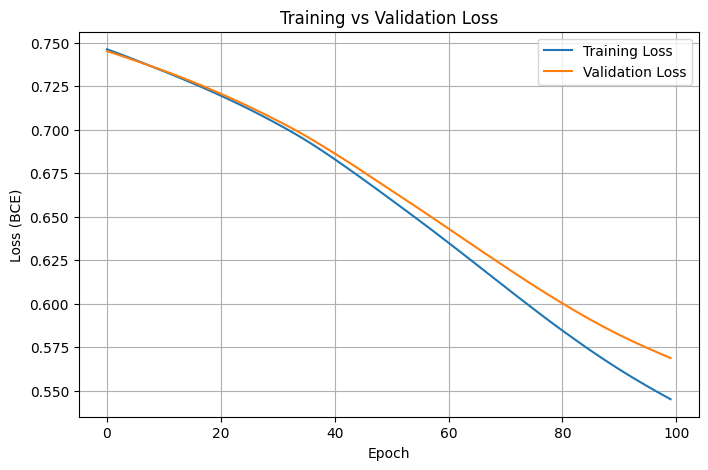

In [18]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.plot(train_losses, label='Training Loss')
plt.plot(val_losses, label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss (BCE)')
plt.title('Training vs Validation Loss')
plt.legend()
plt.grid(True)
plt.show()